<a href="https://colab.research.google.com/github/vhrique/aerogerador_fault_diagnosis/blob/main/PHMAP25_MOEMC_MOEMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://github.com/vhrique/aerogerador_fault_diagnosis/raw/refs/heads/main/running_tries-20250521T184947Z-1-001.zip /content/. >> log.txt
!unzip /content/running_tries-20250521T184947Z-1-001.zip >> log.txt

--2025-05-23 19:00:36--  https://github.com/vhrique/aerogerador_fault_diagnosis/raw/refs/heads/main/running_tries-20250521T184947Z-1-001.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/vhrique/aerogerador_fault_diagnosis/refs/heads/main/running_tries-20250521T184947Z-1-001.zip [following]
--2025-05-23 19:00:37--  https://raw.githubusercontent.com/vhrique/aerogerador_fault_diagnosis/refs/heads/main/running_tries-20250521T184947Z-1-001.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24471812 (23M) [application/zip]
Saving to: ‘running_tries-20250521T184947Z-1-001.zip’

running_tries-20250 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from scipy.stats import wilcoxon
from sklearn.linear_model import LinearRegression

In [3]:
filenames = list(glob('/content/running_tries/*_trie_*/trie_decomp.xlsx'))

In [4]:
experiment_dict = {
    1: [200, 30, 20],
    2: [150, 20, 20],
    3: [100, 10, 20],
    4: [50, 30, 20],
    5: [25, 20, 20],
    6: [200, 10, 15],
    7: [150, 30, 15],
    8: [100, 20, 15],
    9: [50, 10, 15],
    10: [25, 30, 15],
    11: [200, 20, 10],
    12: [150, 10, 10],
    13: [100, 30, 10],
    14: [50, 20, 10],
    15: [25, 10, 10],
}

In [5]:
experiment = []
complexity = []
error_test = []
error_opt = []
trial = []
types = []
classifiers = []
generations = []
population = []

for fn in filenames:
    df = pd.read_excel(fn)
    df = df.iloc[1:]

    trial_number = int(fn.split('_trie_')[-1][0])
    trial.extend([trial_number] * len(df))

    types.extend(['moems' if 'MOEMS' in fn else 'moemc'] * len(df))

    experiments = df.index.tolist()
    experiment.extend(experiments)
    classifiers.extend([experiment_dict[e][0] for e in experiments])
    generations.extend([experiment_dict[e][1] for e in experiments])
    population.extend([experiment_dict[e][2] for e in experiments])

    complexity.extend(df.complex.tolist())
    error_test.extend(df.error_test.tolist())
    error_opt.extend(df.error_valid.tolist())

df = pd.DataFrame({
    'type': types,
    'trial': trial,
    'experiment': experiment,
    'classifiers': classifiers,
    'generations': generations,
    'population': population,
    'complexity': complexity,
    'error_test': error_test,
    'error_opt': error_opt
})

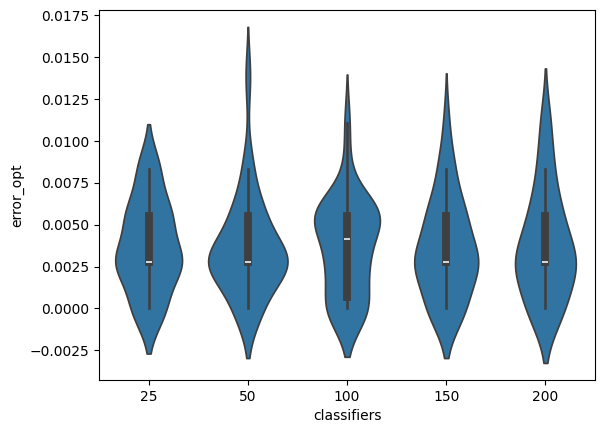

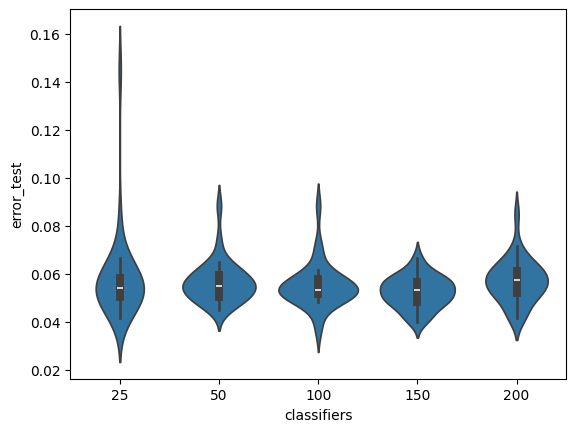

In [6]:
sns.violinplot(x="classifiers", y="error_opt", data=df.query('type == "moemc"'))
plt.show()

sns.violinplot(x="classifiers", y="error_test", data=df.query('type == "moemc"'))
plt.show()

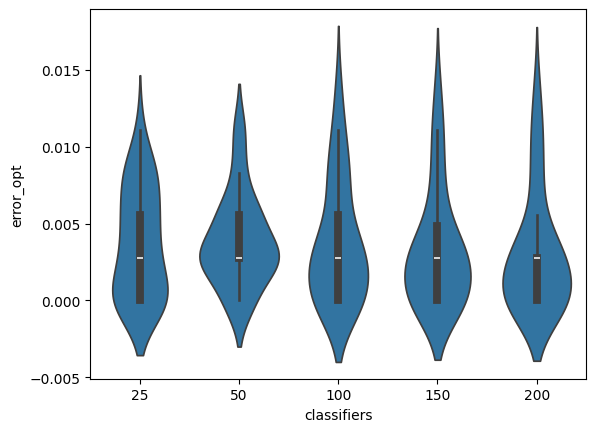

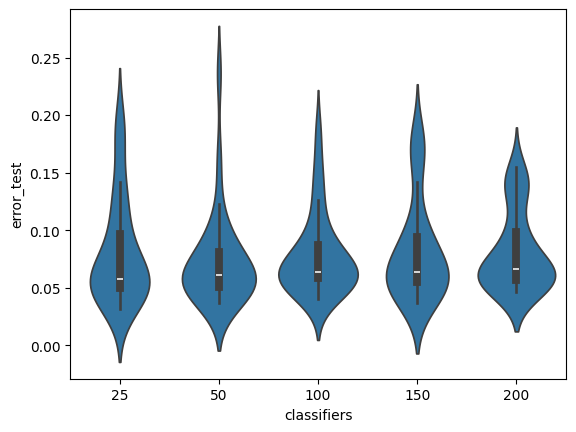

In [7]:
sns.violinplot(x="classifiers", y="error_opt", data=df.query('type == "moems"'))
plt.show()

sns.violinplot(x="classifiers", y="error_test", data=df.query('type == "moems"'))
plt.show()

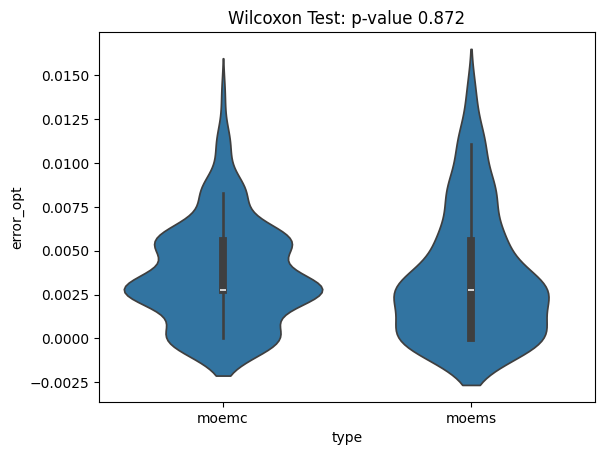

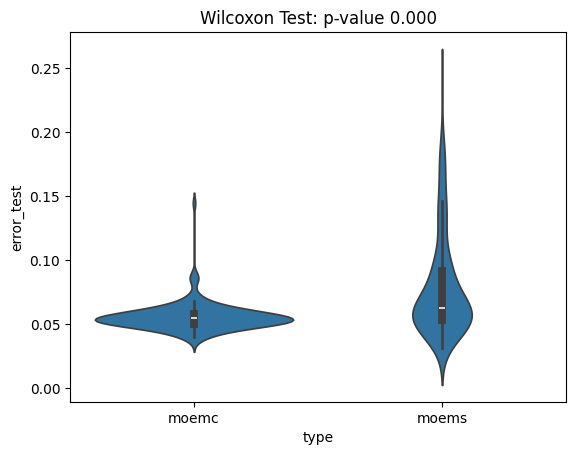

In [8]:
sns.violinplot(x="type", y="error_opt", data=df)
stat, p_value = wilcoxon(
    df.query('type == "moems"').error_opt,
    df.query('type == "moemc"').error_opt
)
plt.title(f'Wilcoxon Test: p-value {p_value:.3f}')
plt.show()

sns.violinplot(x="type", y="error_test", data=df)
stat, p_value = wilcoxon(
    df.query('type == "moems"').error_test,
    df.query('type == "moemc"').error_test
)
plt.title(f'Wilcoxon Test: p-value {p_value:.3f}')
plt.show()

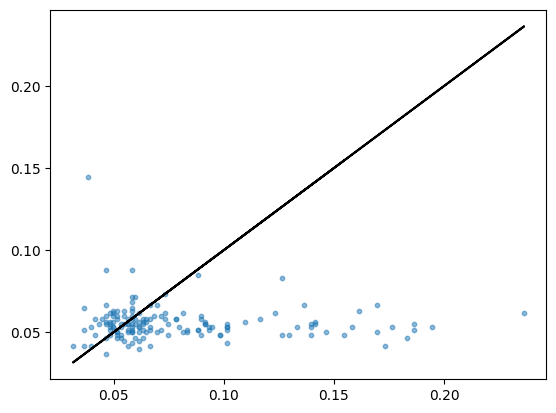

In [51]:
y_1 = df.query('type == "moems"').sort_values(by='experiment').error_test
y_2 = df.query('type == "moemc"').sort_values(by='experiment').error_test
plt.scatter(y_1, y_2, s=10, alpha=0.5)
plt.plot(y_1, y_1, c='k')
plt.show()